## Fidelities with Common Randomized Measurements

With common randomized measurements [Vermersch, al, PRXQ 2024](https://doi.org/10.1103/PRXQuantum.5.010352), a classical approximation $\sigma$ of an experimental state $\rho$ is used to facilitate the measurement of physical properties. 

In this tutorial, we will illustrate in the context of the measurement of the fidelity $\mathcal{F}=\mathrm{Tr}(\rho \sigma)$, where $\sigma=\ket{\psi}\bra{\psi}$.

Note that in this example,  $\sigma$ is at the same time the observable we are interested in, and the classical approximation we used for building common randomized measurements.

In [1]:
using RandomMeas

We begin by considering $\sigma=\ket{\psi}\bra{\psi}$ ($\rho$) as the output of an ideal (noisy, respectively) $2$-qubit quantum circuit of various depths $d$

In [2]:
N = 4
depth = 5
cutoff = 1e-4
ξ = siteinds("Qubit", N)
ψ,ρ,F = MPS[], MPO[], Float64[]

#initial states
push!(ψ,MPS(ξ, ["Dn" for n in 1:N]));
push!(ρ,outer(ψ[1]',ψ[1]));
push!(F,1.)

#random circuit and noise parameters
circuit = random_circuit(ξ,depth)
p = 0.1*rand(N)
@showprogress dt=1 for d in 1:depth
            push!(ψ,apply(circuit,ψ[d];cutoff=cutoff))
            ρt = apply(circuit,ρ[d],apply_dag=true;cutoff=cutoff)
            #each random circuit layer is followed by local depolarization with probabilities p 
            push!(ρ,apply_depo_channel(ρt,p));  

            push!(F,real(inner(ψ[d+1]',ρ[d+1],ψ[d+1])))
end


Progress: 100%|█████████████████████████████████████████| Time: 0:00:50


We first perform randomized measurement on the experimental state, and store the unitaries $u$ that we used

In [3]:
#Perform Randomized measurements
NU=200
NM=2000

measurement_group = Vector{MeasurementGroup}(undef,depth+1)
@showprogress dt=1 for d in 1:depth+1
    measurement_group[d] = MeasurementGroup(ρ[d],NU,NM;mode=Dense);
end

Progress: 100%|█████████████████████████████████████████| Time: 0:00:11


From randomized measurement, we know that we can build estimate the fidelity $\mathcal{F}$ as $\mathcal{F}_e=\mathrm{tr}(\sigma \hat{\rho})$ with the shadows $\hat{\rho}$. 

In [4]:
F_e = zeros(Float64,depth+1)
for d in 1:depth+1
    shadow_d = get_dense_shadows(measurement_group[d])
    F_e[d] = real(get_expect_shadow(outer(ψ[d]',ψ[d]),shadow_d))
end

CRM provide a more efficient estimator $\mathcal{F}_{CRM}=\mathrm{tr}(\sigma \hat{\rho})-\mathrm{tr}(\sigma \hat{\sigma})+1$ based on  using the simulated shadow $\hat{\sigma}$, which is generated numerically from the Born probabilities $P_0(s)=\langle s|u\sigma u^\dag|s\rangle$.

In [5]:
F_CRM = copy(F_e).+1

for d in 1:depth+1
    for r in 1:NU
        data = measurement_group[d].measurements[r]
        P = MeasurementProbability(ψ[d],data.measurement_setting)
        shadow_sigma = DenseShadow(P)
        F_CRM[d] -= real(get_expect_shadow(outer(ψ[d]',ψ[d]),shadow_sigma))/NU
    end
end

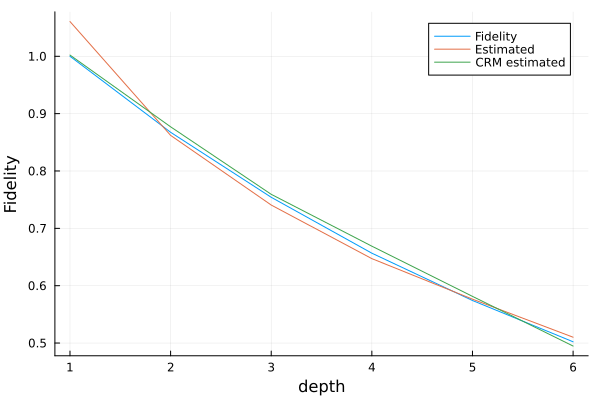

In [6]:
using Plots
Plots.plot(1:depth+1,F,label="Fidelity")
plot!(1:depth+1,F_e,label="Estimated")
plot!(1:depth+1,F_CRM,label="CRM estimated")
xlabel!("depth")
ylabel!("Fidelity")

In [7]:
N = 4
# 量子ビットの数。ここでは4ビットの小規模な系で実験します。

depth = 5
# 量子回路の深さ（ゲートを何層かけるか）。時間が経つほど状態が複雑になります。

cutoff = 1e-4
# 【ITensors特有】テンソルネットワークの近似精度。
# 行列の特異値分解（SVD）をする際、これより小さい値は切り捨てて計算を軽くします。

ξ = siteinds("Qubit", N)
# 【ITensors特有】"Qubit"（2次元）のインデックス（足）をN個作ります。
# 物理的には「量子ビットがN個ある場所」を定義しています。

ψ, ρ, F = MPS[], MPO[], Float64[]
# データを保存するための空の配列（リスト）を用意します。
# ψ (プサイ): 理想的な純粋状態 (MPS: Matrix Product State)
# ρ (ロー): ノイズありの混合状態 (MPO: Matrix Product Operator)
# F (フィデリティ): 真の忠実度の値 (Float64: 倍精度浮動小数点数)
# Pythonなら `psi = []` と書くところですが、Juliaは型を指定すると速いです。

# --- 初期状態 (t=0) の作成 ---
push!(ψ, MPS(ξ, ["Dn" for n in 1:N]))
# `push!`: 配列の末尾に要素を追加（Pythonの `.append()`）。
# `MPS(...)`: 全てのスピンがダウン（"Dn" = |0>）の状態 |0000> を作ります。
# これが「理想的な初期状態」です。

push!(ρ, outer(ψ[1]', ψ[1]))
# `outer`: ベクトル同士の外積をとって行列（密度行列）を作ります。
# ρ = |ψ><ψ|。最初はノイズがないので、理想状態と同じです。

push!(F, 1.)
# 初期状態なので、理想状態との重なり（忠実度）は 1.0 (100%) です。


1-element Vector{Float64}:
 1.0

In [8]:
circuit = random_circuit(ξ, depth)
# 指定した深さ `depth` 分のランダムな量子ゲート（回路）を生成します。
# 論文 Page 5, Sec III.C の "unidimensional random circuit" に対応します。

p = 0.1 * rand(N)
# 各量子ビットに入るノイズの強さ（確率）をランダムに決めています。
# 最大10%程度の確率でエラーが起きる設定です。
# rand(N) は、Juliaにおいて**「0から1の間の乱数（一様分布）を $N$ 個生成して、配列（ベクトル）にする関数」**
# これによって、例えば p = [0.012, 0.089, 0.045, 0.002] のような配列ができます。

@showprogress dt=1 for d in 1:depth
# 1層ずつループを回します。`@showprogress` でバーが出ます。
# dt は "Delta time" の略で、「プログレスバーの画面更新を行う、最小の時間間隔（秒）」 を指定しています。

    # --- 1. 理想状態 (Theory) の更新 ---
    push!(ψ, apply(circuit, ψ[d]; cutoff=cutoff))
    # `apply`: ゲート演算（ユニタリ行列 U）を状態に掛けます。
    # |ψ(t+1)> = U |ψ(t)>
    # ノイズは入れません（これが「理論上の正解」だから）。

    # --- 2. 実験状態 (Experiment) の更新 ---
    ρt = apply(circuit, ρ[d], apply_dag=true; cutoff=cutoff)
    # 密度行列 ρ に対する時間発展です。
    # ρ(t+1) = U ρ(t) U† (Uダガー)
    # `apply_dag=true` が「後ろからU†を掛ける」処理をやってくれます。

    # --- 3. ノイズの付与 ---
    push!(ρ, apply_depo_channel(ρt, p))
    # ここで実験状態にだけ「脱分極ノイズ (Depolarization noise)」を加えます。
    # 状態が少しだけ「完全混合状態」に近づきます。
    # 論文 Page 5, "Each gate is subject to local depolarization noise" に対応。
    # rhoとpの見分けに注意

    # --- 4. 真の忠実度 (True Fidelity) の計算 ---
    push!(F, real(inner(ψ[d+1]', ρ[d+1], ψ[d+1])))
    # `inner`: 内積や期待値を計算します。
    # 計算式: <ψ| ρ |ψ>
    # これが「答え合わせ」のための真の値です。
end


Progress: 100%|█████████████████████████████████████████| Time: 0:00:05


function get_expect_shadow(O::MPO, shadow::DenseShadow)
    N = shadow.N
    ξ = shadow.site_indices
    X = 1 * shadow.shadow_data'
    for i in 1:N
        s = ξ[i]
        X *= O[i] * δ(s, s'')
    end
    return X[]  # Return the full complex value
end

In [9]:
# Perform Randomized measurements
NU = 200
# ランダムユニタリ（回転）の数。論文中の N_U に対応。
# 200パターンの違う測定設定を試します。

NM = 2000
# ショット数。論文中の N_M に対応。
# 1つの設定につき2000回測定して統計を取ります。

measurement_group = Vector{MeasurementGroup}(undef, depth+1)
# 測定データを格納する配列を確保。

@showprogress dt=1 for d in 1:depth+1
    measurement_group[d] = MeasurementGroup(ρ[d], NU, NM; mode="dense")
    # 実験状態 `ρ[d]` に対してランダム測定を行います。
    # 結果（0101...のようなビット列の集まり）が `measurement_group` に保存されます。
    # これが「実験データ」です。
end


TypeError: TypeError: in keyword argument mode, expected SimulationMode, got a value of type String

In [10]:
F_e = zeros(Float64, depth+1)
# 推定結果を入れる配列（全部ゼロで初期化）。

for d in 1:depth+1
    shadow_d = get_dense_shadows(measurement_group[d])
    # 測定データから「クラシカルシャドウ（状態の復元図）」 ρ_hat を作ります。
    # 論文 Eq. (1): ρ_hat^(r) = ... の式に相当します。

    F_e[d] = real(get_expect_shadow(outer(ψ[d]', ψ[d]), shadow_d))
    # get_expect_shadowのなかみを探る。
    # シャドウを使って忠実度を推定します。
    # 計算式: F_e = Tr( |ψ><ψ| * ρ_hat )
    # `outer(ψ[d]', ψ[d])` は、測りたい物理量（理想状態そのもの）です。
end


UndefRefError: UndefRefError: access to undefined reference

In [11]:
F_CRM = copy(F_e) .+ 1
# CRMの推定値を計算するための配列準備。
# まず、さっき計算した「従来手法の値 (F_e)」をコピーし、それに +1 しておきます。
# なぜ +1 するかは後述の式の変形でわかります。

for d in 1:depth+1
    for r in 1:NU
        # 全てのユニタリ（測定設定） r についてループします。

        data = measurement_group[d].measurements[r]
        # その時の実験条件（どのランダム回転を使ったか）を取り出します。

        # --- 論文 Eq. (3) 相当の計算 ---
        P = MeasurementProbability(ψ[d], data.measurement_setting)
        # 「もし理想状態 ψ だったら、どういう確率分布になったか？」を計算します。
        # これがシミュレーションです（Born probabilities）。

        shadow_sigma = DenseShadow(P)
        # その確率分布を使って、「理想状態のシャドウ (σ_hat)」を作ります。
        # 論文中の σ^(r) に対応します。

        # --- 論文 Eq. (2) の適用 ---
        # 論文の式: F_CRM = Tr(σ * ρ_hat_CRM)
        #          = Tr(σ * (ρ_hat - σ_hat + σ))
        #          = Tr(σ * ρ_hat) - Tr(σ * σ_hat) + Tr(σ * σ)
        # ここで、
        #   Tr(σ * ρ_hat) = F_e (さっき計算した従来手法の値)
        #   Tr(σ * σ) = Tr(|ψ><ψ| * |ψ><ψ|) = 1 (純粋状態なので1)
        #
        # よってコード上の計算式は：
        #   F_CRM = (F_e + 1) - Tr(σ * σ_hat)
        # となります。

        F_CRM[d] -= real(get_expect_shadow(outer(ψ[d]', ψ[d]), shadow_sigma)) / NU
        # ここで引いているのが Tr(σ * σ_hat) の部分です。
        # ユニタリ設定ごとの平均を取るため、NU で割っています。
    end
end


UndefRefError: UndefRefError: access to undefined reference

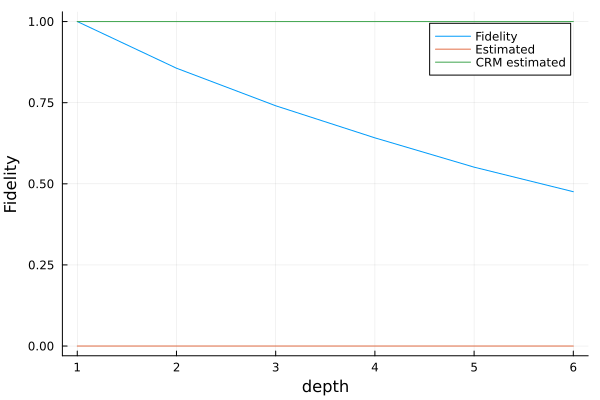

In [12]:
using Plots
Plots.plot(1:depth+1, F, label="Fidelity")
# 真の値（正解）。計算機だからわかる値。

plot!(1:depth+1, F_e, label="Estimated")
# 従来手法。データ数が有限なので、正解からズレてガタガタします。

plot!(1:depth+1, F_CRM, label="CRM estimated")
# CRM手法。従来手法より圧倒的に「Fidelity（正解）」に近いラインに乗るはずです。
# 論文 Figure 3 (a), (b) で「CRMのエラーバーが小さい」と示されている現象と同じです。

xlabel!("depth")
ylabel!("Fidelity")
# 軸のラベル付け。


Generating states at depth = 3 ...
True Fidelity at depth 3: 0.8718387177278232
Starting estimation loop with varying NU and NM...
Total=100 (NU=10, NM=10): Std=0.888, CRM=0.887
Total=300 (NU=15, NM=20): Std=0.851, CRM=0.882
Total=1000 (NU=20, NM=50): Std=0.869, CRM=0.867
Total=5000 (NU=50, NM=100): Std=0.873, CRM=0.872
Total=20000 (NU=100, NM=200): Std=0.875, CRM=0.871
Total=100000 (NU=200, NM=500): Std=0.884, CRM=0.872
Total=500000 (NU=500, NM=1000): Std=0.877, CRM=0.872


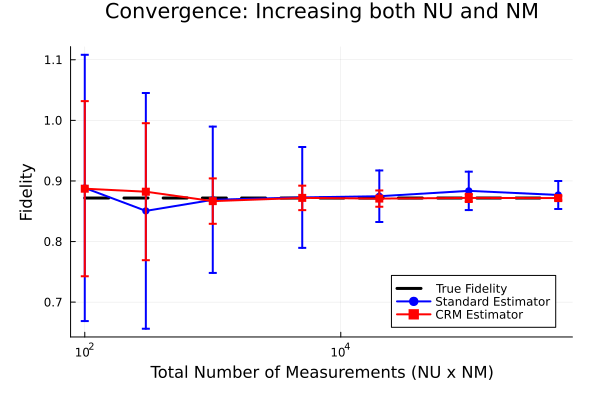

In [13]:
using ITensors
using RandomMeas
using Plots
using Statistics

# --- 1. 初期設定と状態準備 ---
N = 4           # 量子ビット数
depth = 3       # 回路の深さ
cutoff = 1e-4   # SVDの切り捨て誤差

# 変数の準備
ξ = siteinds("Qubit", N)
ψ = MPS(ξ, ["Dn" for n in 1:N])     # 理想状態 (Prior)
ρ = outer(ψ', ψ)                    # 実験状態 (Target)
circuit = random_circuit(ξ, depth)  # ランダム回路生成
p = 0.05 * rand(N)                  # ノイズ強度

println("Generating states at depth = $depth ...")
# 時間発展
@showprogress dt=1 for d in 1:depth
    global ψ = apply(circuit, ψ; cutoff=cutoff)
    ρt = apply(circuit, ρ, apply_dag=true; cutoff=cutoff)
    global ρ = apply_depo_channel(ρt, p)
end

# 「正解」のFidelity
true_fidelity = real(inner(ψ', ρ, ψ))
println("True Fidelity at depth $depth: $true_fidelity")

# --- 2. NUとNMの両方を変化させながら実験 ---

# 実験設定のリスト: (NU, NM)
# 両方のパラメータを徐々に増やしていきます
settings_list = [
    (nu=10,   nm=10),    # Total = 100
    (nu=15,   nm=20),    # Total = 300
    (nu=20,   nm=50),    # Total = 1,000
    (nu=50,   nm=100),   # Total = 5,000
    (nu=100,  nm=200),   # Total = 20,000
    (nu=200,  nm=500),   # Total = 100,000
    (nu=500,  nm=1000)   # Total = 500,000
]

n_repeat = 15  # エラーバー用の試行回数

# 結果保存用
total_shots_list = Float64[]
mean_standard = Float64[]
std_standard  = Float64[]
mean_crm      = Float64[]
std_crm       = Float64[]

println("Starting estimation loop with varying NU and NM...")

for (nu, nm) in settings_list
    total_shots = nu * nm
    push!(total_shots_list, total_shots)
    
    # 一時保存用
    temp_standard = Float64[]
    temp_crm = Float64[]
    
    for i in 1:n_repeat
        # A. 実験データの生成
        # そのループの nu, nm を使用
        mg = MeasurementGroup(ρ, nu, nm; mode=RandomMeas.Dense)
        
        # B. Standard Estimator
        shadow_rho = get_dense_shadows(mg)
        f_est = real(get_expect_shadow(outer(ψ', ψ), shadow_rho))
        push!(temp_standard, f_est)
        
        # C. CRM Estimator
        term_correction = 0.0
        # 補正ループも nu 回分回す
        for r in 1:nu
            setting = mg.measurements[r].measurement_setting
            P_sigma = MeasurementProbability(ψ, setting)
            shadow_sigma = DenseShadow(P_sigma)
            term_correction += real(get_expect_shadow(outer(ψ', ψ), shadow_sigma))
        end
        # 平均は nu で割る
        f_crm = f_est - (term_correction / nu - 1.0)
        push!(temp_crm, f_crm)
    end
    
    # 統計処理
    push!(mean_standard, mean(temp_standard))
    push!(std_standard,  std(temp_standard))
    push!(mean_crm,      mean(temp_crm))
    push!(std_crm,       std(temp_crm))
    
    println("Total=$(Int(total_shots)) (NU=$nu, NM=$nm): Std=$(round(mean(temp_standard), digits=3)), CRM=$(round(mean(temp_crm), digits=3))")
end

# --- 3. プロット作成 ---

true_line = fill(true_fidelity, length(total_shots_list))

p1 = plot(total_shots_list, true_line, 
    label="True Fidelity", 
    lw=3, color=:black, linestyle=:dash,
    xlabel="Total Number of Measurements (NU x NM)",
    ylabel="Fidelity",
    title="Convergence: Increasing both NU and NM",
    legend=:bottomright,
    xscale=:log10,
    margin=5Plots.mm
)

plot!(p1, total_shots_list, mean_standard, 
    yerror=std_standard,
    label="Standard Estimator", 
    marker=:circle, lw=2, color=:blue,
    msc=:blue
)

plot!(p1, total_shots_list, mean_crm, 
    yerror=std_crm,
    label="CRM Estimator", 
    marker=:square, lw=2, color=:red,
    msc=:red
)

display(p1)